1.A cloth manufacturing company is interested to know about the different attributes contributing to high 
sales. Build a decision tree & random forest model with Sales as target variable 
(first convert it into categorical variable).

Understanding and classfication of the Sales 


What are different attributes to classfication of given Sales according regan
1) coustemer is Urban or not 
2) classfing the Data base on US

UnderStanding the feature in the give Data

In [198]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier ,plot_tree 
from sklearn.ensemble import RandomForestClassifier 

import plotly.express as px 
df=pd.read_csv("E:/Data Science/13-Decision Tree/Company_Data.csv")
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


In [208]:
df.shape

(400, 11)

df.isnull().sum()

In [ ]:
# histogroam 
def col_histogream(col)  :  
    sns.histplot(df[col])

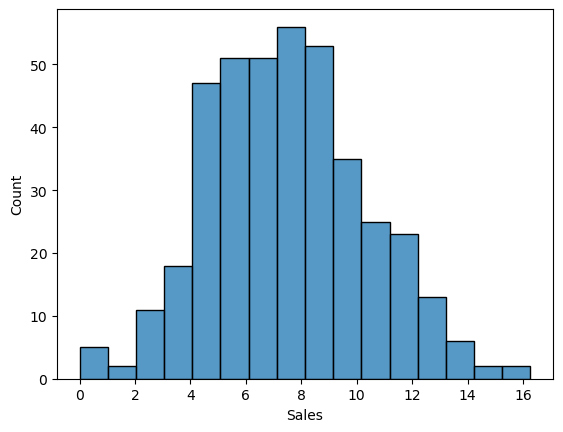

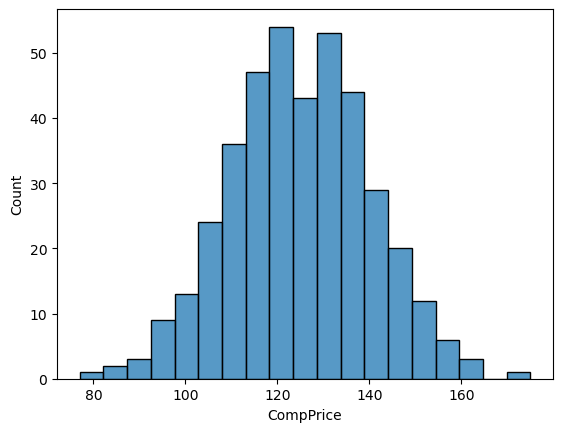

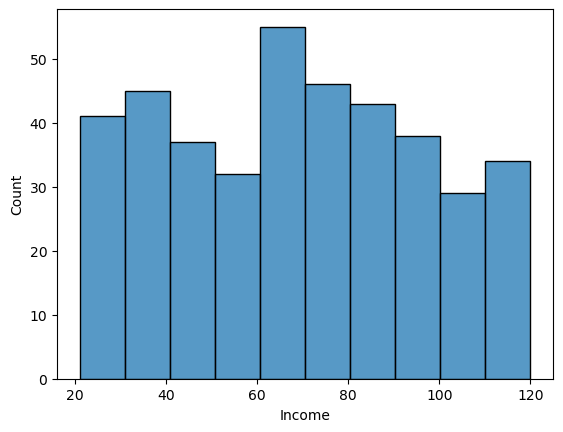

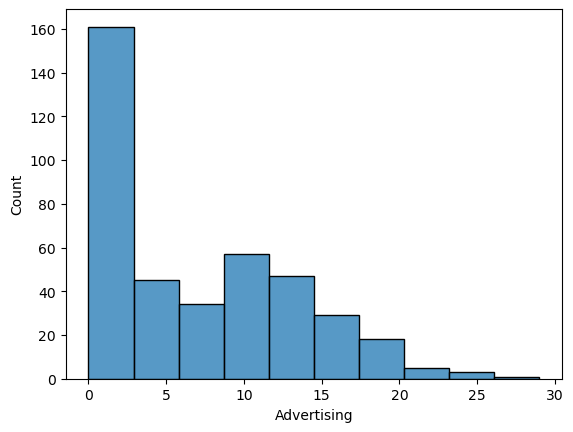

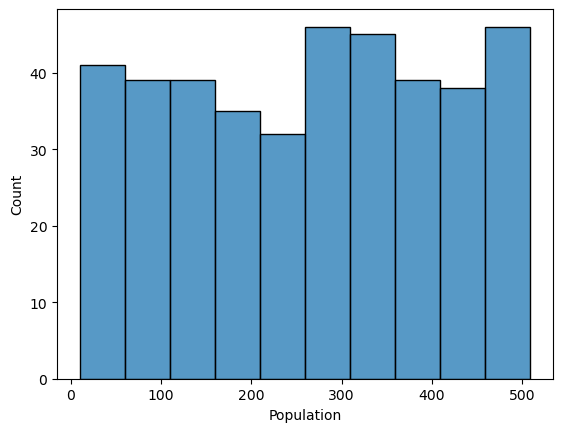

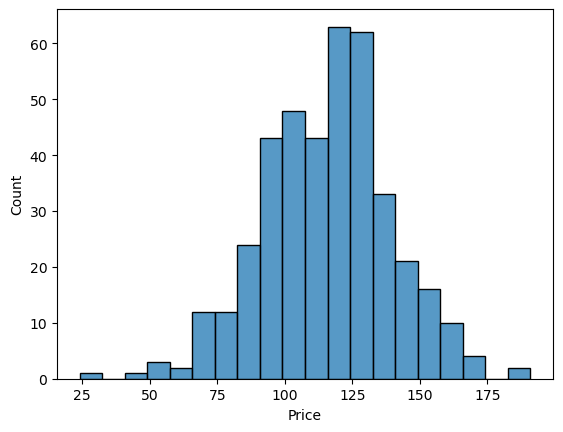

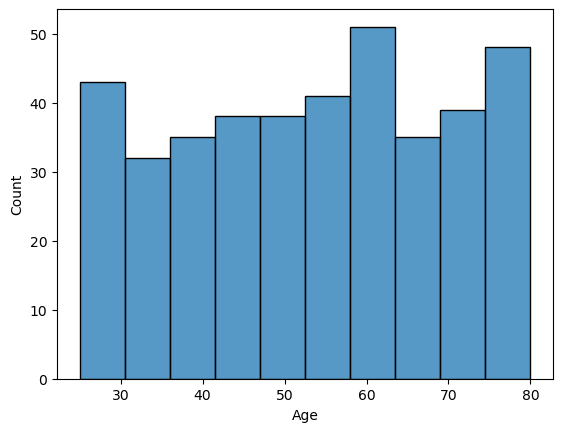

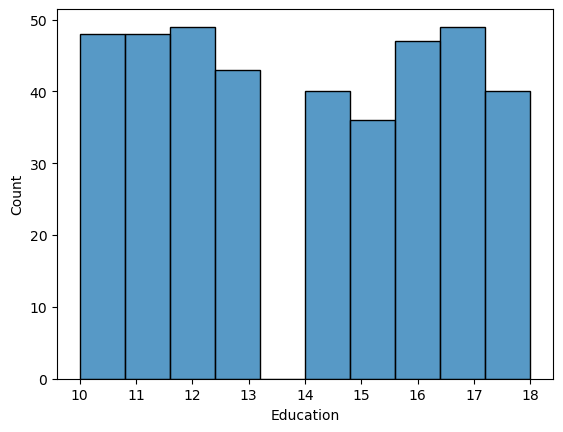

In [49]:
num=['Sales','CompPrice','Income','Advertising','Population','Price','Age','Education']
for i in num: 
    col_histogream(i)
    plt.show()

In [55]:
# Power transformer on given graphs 
#1) Income , Advertising  , Education

In [57]:
#outer ditation 
def box_plot(col): 
    sns.boxplot(df[col]) 

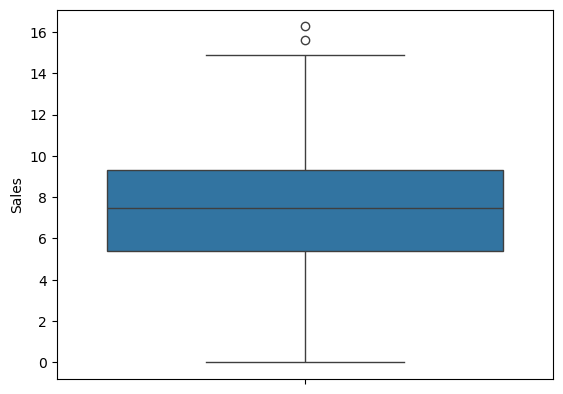

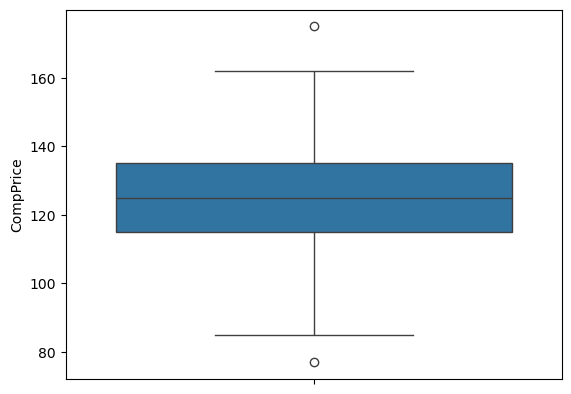

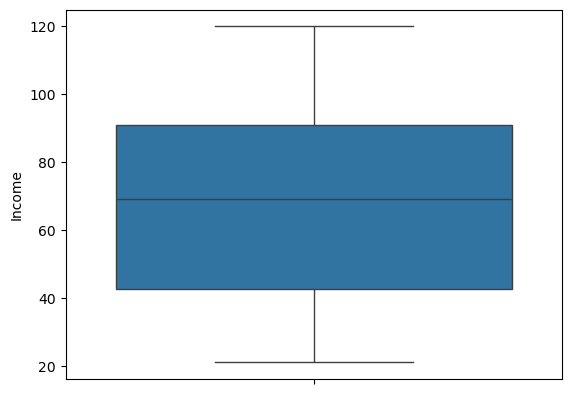

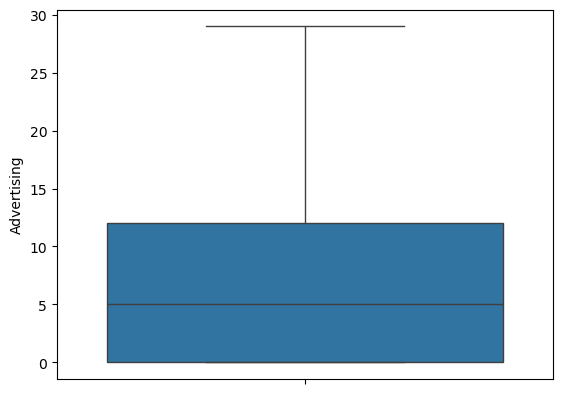

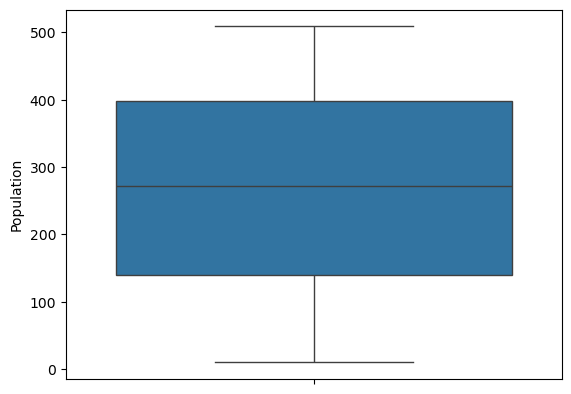

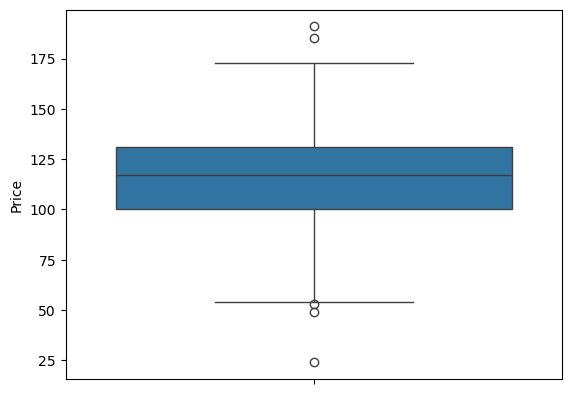

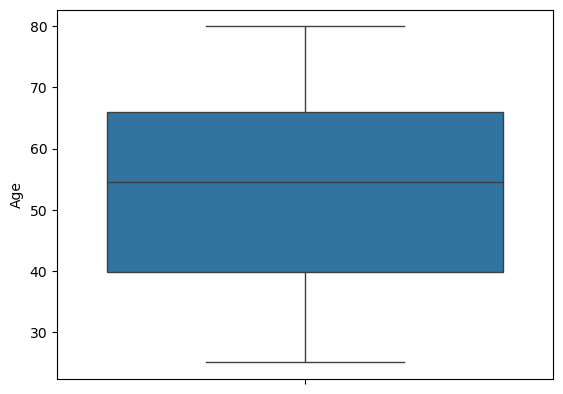

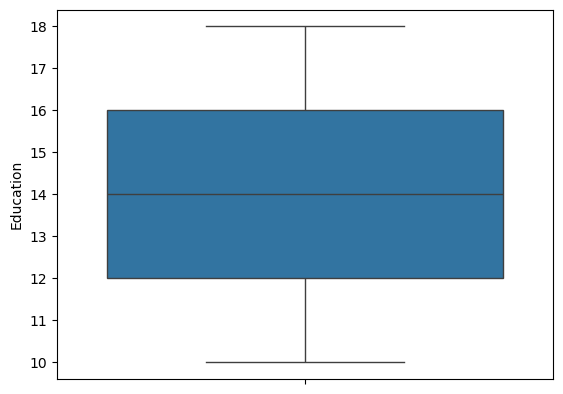

In [59]:
for i in num : 
    box_plot(i)
    plt.show()

In [61]:
# no outler in data 

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


In [65]:
cat=['ShelveLoc','Urban','US'] 

In [67]:
# heat map 
k=pd.crosstab(df['ShelveLoc'],df['Urban'])
k

Urban,No,Yes
ShelveLoc,,
Bad,22,74
Good,28,57
Medium,68,151


In [72]:
# Steps 1) Label incoder 
     #   2) Ordinal incoder 
        #2) power transfromer 

In [174]:
 lab= LabelEncoder() 

In [176]:
set(df['ShelveLoc'])

{'Bad', 'Good', 'Medium'}

In [178]:
ord=OrdinalEncoder(categories=[['Bad','Medium','Good']])

In [179]:
df['ShelveLoc']=ord.fit_transform(df[['ShelveLoc']])

In [181]:
df.sample(4)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
128,4.96,133,100,3,350,126,0.0,55,13,1,1
133,7.62,132,98,2,265,97,0.0,62,12,1,1
390,5.47,108,75,9,61,111,1.0,67,12,1,1
153,5.93,150,36,7,488,150,1.0,25,17,0,1


In [211]:
df['ShelveLoc'].value_counts()

ShelveLoc
Medium    219
Bad        96
Good       85
Name: count, dtype: int64

In [213]:
df['Urban']=lab.fit_transform(df['Urban'])

In [215]:
df['US']=lab.fit_transform(df['US'])

In [227]:
df['ShelveLoc']=lab.fit_transform(df['ShelveLoc'])

In [229]:
df

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,0,42,17,1,1
1,11.22,111,48,16,260,83,1,65,10,1,1
2,10.06,113,35,10,269,80,2,59,12,1,1
3,7.40,117,100,4,466,97,2,55,14,1,1
4,4.15,141,64,3,340,128,0,38,13,1,0
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,1,33,14,1,1
396,6.14,139,23,3,37,120,2,55,11,0,1
397,7.41,162,26,12,368,159,2,40,18,1,1
398,5.94,100,79,7,284,95,0,50,12,1,1


In [231]:
X=df.iloc[:,:-1]
y=df[['US']]

In [233]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [235]:
clf1=DecisionTreeClassifier()
clf2=RandomForestClassifier()
clf3=XGBClassifier()

In [237]:
clf1.fit(X_train,y_train)

DecisionTreeClassifier()

In [239]:
clf2.fit(X_train,y_train)

C:\Users\samir\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier()

In [241]:
clf3=clf3.fit(X_train,y_train)

In [243]:
#prediction 
y_pre1=clf1.predict(X_test)
y_pre2=clf2.predict(X_test)
y_pre3=clf3.predict(X_test)

In [255]:
from sklearn.metrics import accuracy_score 
accuracy_score(y_test,y_pre1)

0.8125

In [247]:
accuracy_score(y_test,y_pre2)

0.925

In [249]:
accuracy_score(y_test,y_pre3)

0.925

In [251]:
# for traing data 
y_train_p1=clf1.predict(X_train)
y_train_p2=clf2.predict(X_train)
y_train_p3=clf3.predict(X_train)

In [253]:
print(accuracy_score(y_train,y_train_p1))
print(accuracy_score(y_train,y_train_p2))
print(accuracy_score(y_train,y_train_p3))

1.0
1.0
1.0


In [ ]:
# over fiting on data 

In [ ]:
#Random forest is given good result 

Conclusion:
after this peformaning the decision tree & random forest model i undestand that A cloth manufacturing company is interested to know 
sales. Build a  with Sales as target variable focues on urban points
